In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
imgsize = 256;
batchsize =32;

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage" , 
    shuffle =True,
    image_size = (imgsize , imgsize),
    batch_size = batchsize
)

Found 2152 files belonging to 3 classes.


In [4]:
len(dataset)

68

In [5]:
classnames = dataset.class_names
classnames

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

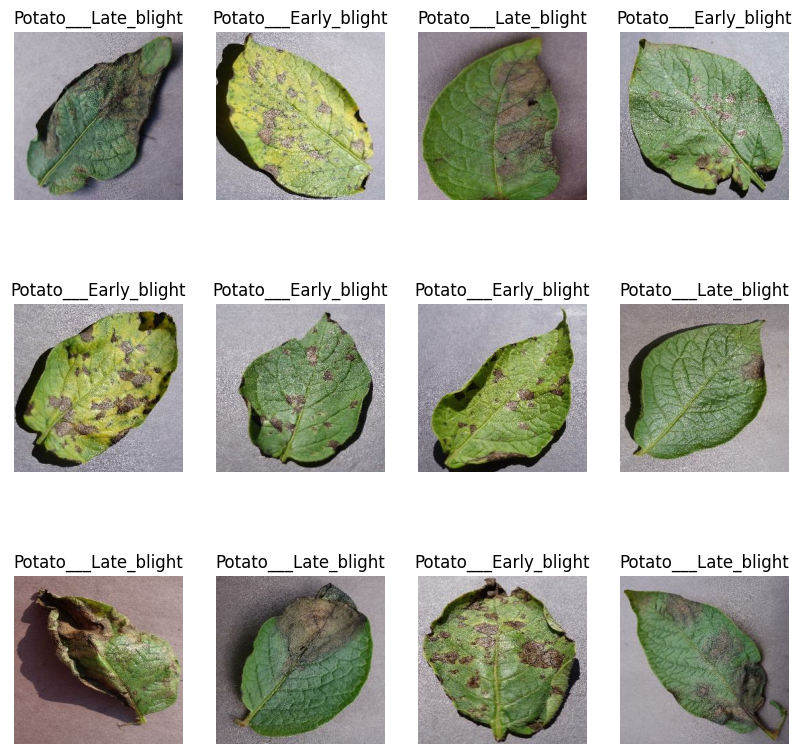

In [6]:
plt.figure(figsize=(10,10));
for imagbatch , labelbatch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(imagbatch[i].numpy().astype("uint8"))
        plt.title(classnames[labelbatch[i]])
        plt.axis("off")

In [7]:
def getdatasets(ds,trainsize=0.8 ,valsize =0.1 ,testsize=0.1 , shuffle =True , shufflesize=10000):


     if shuffle:
         ds =ds.shuffle(shufflesize , seed = 15)
    
     ts = int(trainsize*len(ds))
     vs=int(valsize*len(ds))
     trainds = ds.take(ts)
     valds= ds.skip(ts).take(vs)
     testds = ds.skip(ts).skip(vs)
     return trainds , valds , testds

In [8]:
trainds,valds,testds=getdatasets(dataset)

In [9]:
len(trainds)

54

In [10]:
len(testds)

8

In [11]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(imgsize , imgsize),
  tf.keras.layers.Rescaling(1./255),
])

In [12]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

In [13]:
trainds = trainds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

In [15]:
from tensorflow.keras import layers,models

In [16]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = tf.keras.models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

C:\Users\Aspire Go 14\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    trainds,
    batch_size=BATCH_SIZE,
    validation_data=valds,
    verbose=1,
    epochs=30,
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 741ms/step - accuracy: 0.4935 - loss: 0.8960 - val_accuracy: 0.5208 - val_loss: 0.8140
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 602ms/step - accuracy: 0.6608 - loss: 0.7059 - val_accuracy: 0.7708 - val_loss: 0.5651
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 672ms/step - accuracy: 0.8392 - loss: 0.3762 - val_accuracy: 0.8490 - val_loss: 0.3566
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 639ms/step - accuracy: 0.8797 - loss: 0.3084 - val_accuracy: 0.9115 - val_loss: 0.2163
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 682ms/step - accuracy: 0.9167 - loss: 0.2246 - val_accuracy: 0.9323 - val_loss: 0.2149
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 617ms/step - accuracy: 0.9120 - loss: 0.2052 - val_accuracy: 0.9375 - val_loss: 0.1796
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 709ms/step - accuracy: 0.9079 - loss: 0.2241 - val_accuracy: 0.9010 - val_loss: 0.2710
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 757ms/step - accuracy: 0.9097 - loss: 0.2091 - val_accu

In [19]:
score = model.evaluate(testds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9414 - loss: 0.1188


In [20]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

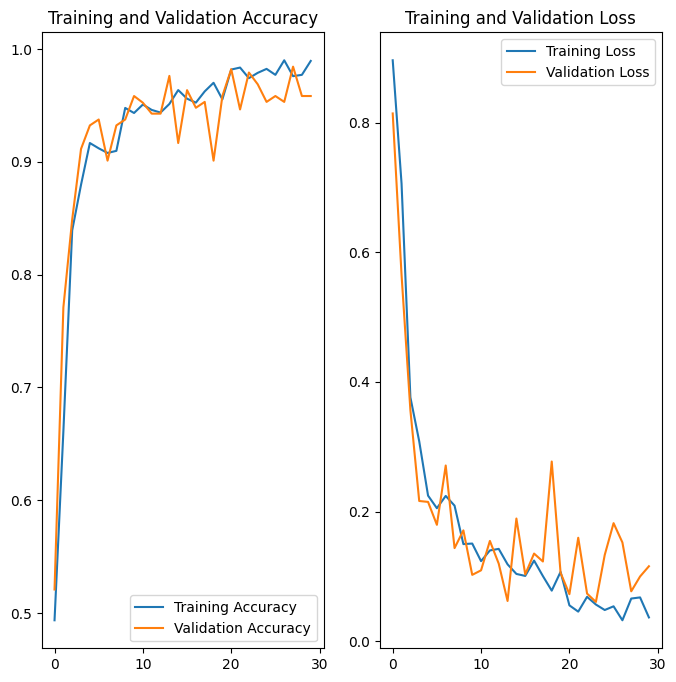

In [23]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(30), acc, label='Training Accuracy')
plt.plot(range(30), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(30), loss, label='Training Loss')
plt.plot(range(30), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [24]:
import numpy as np

def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = classnames[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


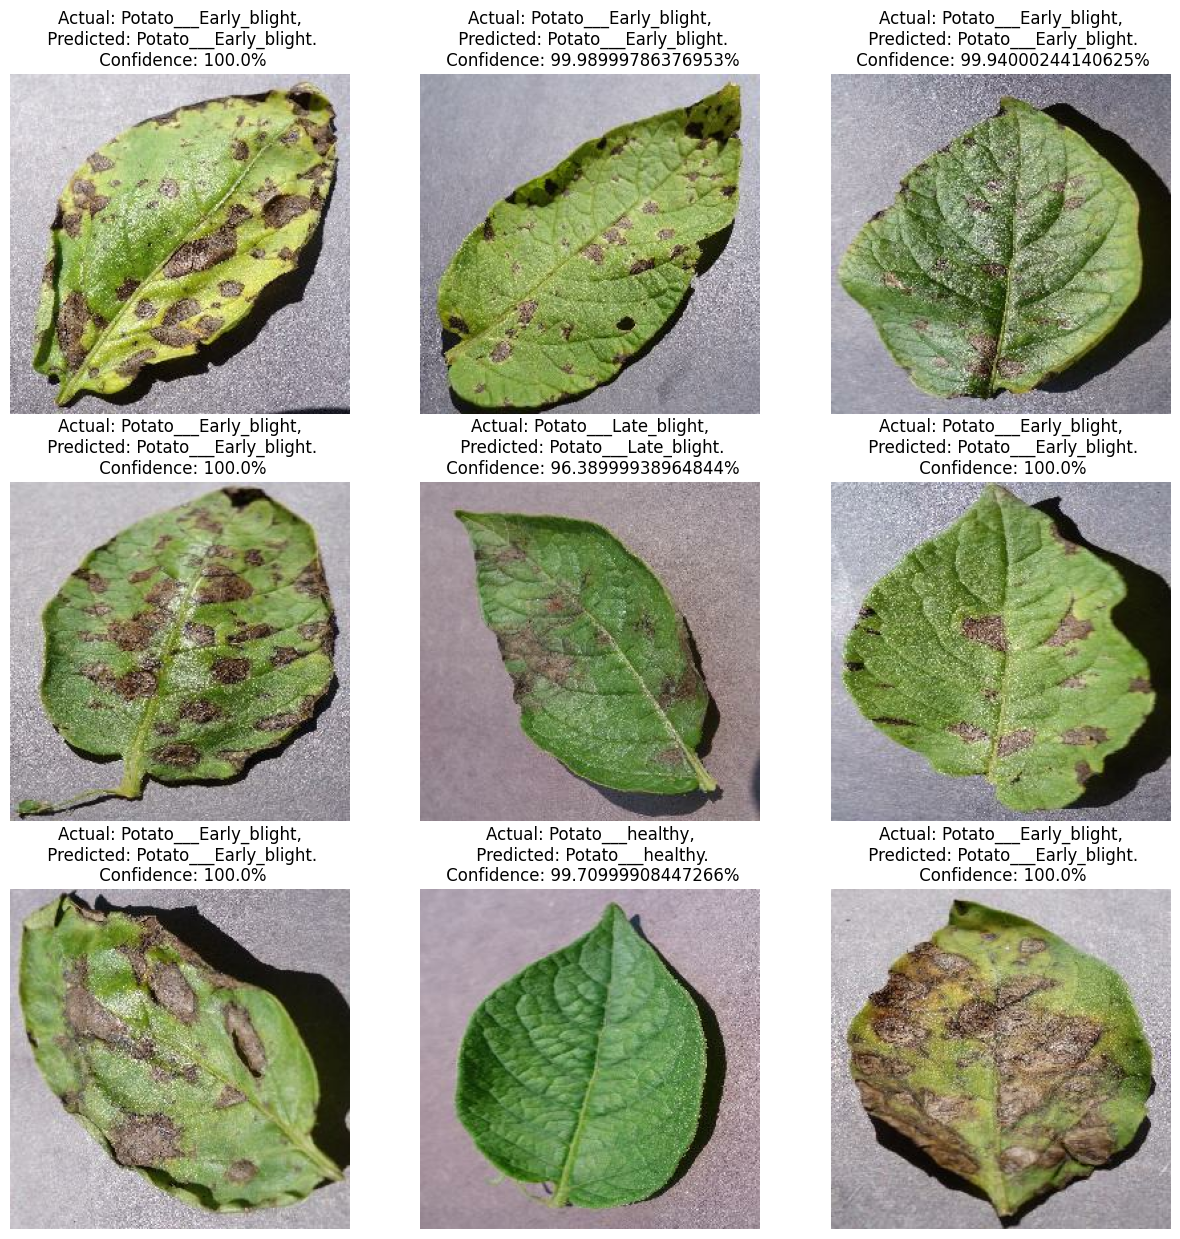

In [25]:
plt.figure(figsize=(15, 15))
for images, labels in testds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = classnames[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [26]:
model.save("../models/model_v2.keras")



In [27]:
import os
print(os.listdir("../models"))



['model_v1.keras', 'model_v2.keras']
